# Task 06 – Model Evaluation & Best Model Selection
### SmartCare Hospital AI Dataset | Option C – Disease Risk Classification
### CCS3440 Artificial Intelligence Coursework

* **ST NAME :** Nilupul Thisaranga (CIT-23-02-0021) | `@N3Edirisinghe`
* **Module:** CCS3440 – Artificial Intelligence
* **Target Variable:** `disease_risk_level` (Multi-Class: 0 = Low, 1 = Medium, 2 = High)

---

### Evaluation Protocol & Governance
This notebook executes independent, unbiased benchmarking on the **unseen holdout test partition (200 records)**. It evaluates the models serialized during Task 05 without retraining or modifying them.
1. **Multi-Class Evaluation Metric Suite:** Accuracy, Macro/Weighted Precision, Recall, F1-Score.
2. **Error Decomposition:** Constructing $3 \times 3$ raw and normalized Confusion Matrices to detect systemic class misclassifications.
3. **Multi-Class ROC-AUC (One-vs-Rest):** Evaluating class separability across all three binary decision thresholds (since the standard AUC is strictly binary).
4. **Model Selection Rationale:** Clinically and statistically justifying the champion architecture based on minority class performance (Low Risk) and overall Macro F1-Score.

**Pipeline Order:**  
`Setup & Artifact Ingestion` ➔ `Prediction Generation` ➔ `Multi-Class Metric Computation` ➔ `Confusion Matrix Diagnostics` ➔ `ROC-AUC (OvR) Analysis` ➔ `Model Comparison Table` ➔ `Champion Model Identification` ➔ `Evaluation Result Serialization`.

## Section 1 — Setup and Ingestion of Test Partitions & Candidate Models

We initialize the environment, load the holdout test splits (`X_test.csv`, `y_test.csv`), and deserialize the tuned candidate models exported by Task 05 (`tuned_model_candidates.pkl`).

In [38]:
import sys
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# Consistent Directory Configuration for Google Drive
BASE_PATH = Path('/content/drive/MyDrive/AI Assignment/processed')
DATA_DIR = BASE_PATH / '/content/drive/MyDrive/AI Assignment/models'
MODELS_DIR = BASE_PATH / '/content/drive/MyDrive/AI Assignment/models'
FIGURES_DIR = BASE_PATH / '/content/drive/MyDrive/AI Assignment/Reports'
# Ensure figure directories exist
EVAL_FIG_DIR = FIGURES_DIR / 'evaluation'
EVAL_FIG_DIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS_DIR = MODELS_DIR / 'predictions'
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

X_TEST_PATH = DATA_DIR / 'X_test.csv'
Y_TEST_PATH = DATA_DIR / 'y_test.csv'

# Formatting and Reproducibility
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42
RISK_ORDER = ['Low', 'Medium', 'High']
CLASS_NAMES = RISK_ORDER
N_CLASSES = len(CLASS_NAMES)

print(f"✅ Environment initialized. Random state: {RANDOM_STATE}")
print(f"✅ Evaluating {N_CLASSES}-class problem: {CLASS_NAMES}")

✅ Environment initialized. Random state: 42
✅ Evaluating 3-class problem: ['Low', 'Medium', 'High']


### Note: Environment and Directory Setup
The cell below initializes the libraries and defines the absolute paths for the project artifacts stored on Google Drive.

In [39]:
# Ingest test split
X_test = pd.read_csv('/content/drive/MyDrive/AI Assignment/processed/X_test.csv')
y_test = pd.read_csv('/content/drive/MyDrive/AI Assignment/processed/y_test.csv').squeeze('columns')

# Ensure absolute path for models to avoid FileNotFoundError
MODELS_DIR_ABS = Path('/content/drive/MyDrive/AI Assignment/models')

# Load Metadata and Models with safety checks
try:
    with open(MODELS_DIR_ABS / 'model_metadata.json') as f:
        model_metadata = json.load(f)
except FileNotFoundError:
    print(f"Warning: model_metadata.json not found at {MODELS_DIR_ABS}")
    model_metadata = {}

model_filenames = {
    'Logistic Regression': 'logistic_regression',
    'Decision Tree': 'decision_tree',
    'Random Forest': 'random_forest',
    'XGBoost': 'xgboost',
}

models = {}
for name, filename in model_filenames.items():
    path = MODELS_DIR_ABS / f'{filename}.pkl'
    try:
        models[name] = joblib.load(path)
    except FileNotFoundError:
        print(f"Warning: {name} model file not found at {path}")

print(f"✅ Loaded {len(models)} trained models: {list(models.keys())}")
print(f"✅ Test set: {X_test.shape[0]} rows, {X_test.shape[1]} features")

✅ Loaded 4 trained models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
✅ Test set: 200 rows, 68 features


## Section 2 — Pre-Evaluation Consistency Check & Prediction Generation

**Audit Requirement:** We verify that the predictions generated dynamically here exactly match the static predictions saved during Task 05[cite: 6]. This ensures no data shift or serialization corruption occurred[cite: 6].

In [43]:
# Consistency check: predictions generated here must match what Task 05 saved
consistency_report = []
for name, filename in model_filenames.items():
    saved = pd.read_csv(PREDICTIONS_DIR / f'{filename}_test_predictions.csv')
    fresh_pred = models[name].predict(X_test)

    matches = (saved['y_pred'].values == fresh_pred).all()
    consistency_report.append({'model': name, 'predictions_match_task05': matches})

consistency_df = pd.DataFrame(consistency_report)
print("=== CONSISTENCY CHECK ===")
print(consistency_df.to_string(index=False))

assert consistency_df['predictions_match_task05'].all(), (
    "Prediction mismatch detected between Task 05's saved predictions and "
    "freshly generated predictions. Do not proceed until resolved."
)
print("\n✅ All models verified: Loaded .pkl files reproduce Task 05's predictions exactly.")

=== CONSISTENCY CHECK ===
              model  predictions_match_task05
Logistic Regression                      True
      Decision Tree                      True
      Random Forest                      True
            XGBoost                      True

✅ All models verified: Loaded .pkl files reproduce Task 05's predictions exactly.


In [46]:
# Generate standard predictions and probabilities for metric computation
predictions = {}
for name, model in models.items():
    # Fix for AttributeError: 'LogisticRegression' object has no attribute 'multi_class'
    # This can occur if the model was saved with an older scikit-learn version
    # or if the attribute was not explicitly set/persisted correctly.
    if name == 'Logistic Regression' and not hasattr(model, 'multi_class'):
        # Assuming 'ovr' (One-vs-Rest) strategy for a multi-class problem
        # as it's a common default for LogisticRegression when handling >2 classes.
        model.multi_class = 'ovr'

    predictions[name] = {
        'y_pred': model.predict(X_test),
        'y_proba': model.predict_proba(X_test),
    }

print(f"✅ Predictions and Probabilities generated for all {len(models)} models.")

✅ Predictions and Probabilities generated for all 4 models.


## Section 3 — Multi-Class Metrics: Precision, Recall, and F1-Score

**Methodological Selection:**  
Due to the imbalanced nature of the dataset (`Low Risk` is the minority), standard Accuracy is insufficient. We compute:
* **Per-Class Metrics:** To observe specific classification behavior for Low, Medium, and High risk patients[cite: 6].
* **Macro F1-Score:** The unweighted mean of F1 scores across all classes. This is our **primary ranking metric**, as it heavily penalizes models that fail to predict the minority class[cite: 6].
* **Weighted F1-Score:** The mean of F1 scores weighted by the number of true instances in each class.

In [48]:
def per_class_metrics(y_true, y_pred, model_name):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1, 2], zero_division=0
    )
    rows = []
    for i, class_name in enumerate(CLASS_NAMES):
        rows.append({
            'model': model_name, 'class': class_name,
            'precision': precision[i], 'recall': recall[i],
            'f1_score': f1[i], 'support': support[i],
        })
    return rows

all_class_metrics = []
for name in models:
    all_class_metrics.extend(per_class_metrics(y_test, predictions[name]['y_pred'], name))

class_metrics_df = pd.DataFrame(all_class_metrics)
print("=== PER-CLASS METRICS TABLE ===")
display(class_metrics_df.round(4))

=== PER-CLASS METRICS TABLE ===


,model,class,precision,recall,f1_score,support
0,Logistic Regression,Low,1.0000,0.8846,0.9388,26
1,Logistic Regression,Medium,0.9255,0.9255,0.9255,94
2,Logistic Regression,High,0.9157,0.9500,0.9325,80
3,Decision Tree,Low,0.7600,0.7308,0.7451,26
4,Decision Tree,Medium,0.7273,0.6809,0.7033,94
5,Decision Tree,High,0.7241,0.7875,0.7545,80
6,Random Forest,Low,0.8824,0.5769,0.6977,26
7,Random Forest,Medium,0.7364,0.8617,0.7941,94
8,Random Forest,High,0.8493,0.7750,0.8105,80
9,XGBoost,Low,0.8696,0.7692,0.8163,26


In [50]:
# Compute aggregated Macro & Weighted metrics
overall_metrics = []
for name in models:
    y_pred = predictions[name]['y_pred']
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted', zero_division=0
    )
    overall_metrics.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'macro_precision': precision,
        'macro_recall': recall,
        'macro_f1': f1,
        'weighted_f1': f1_weighted,
    })

overall_metrics_df = pd.DataFrame(overall_metrics).sort_values('macro_f1', ascending=False).reset_index(drop=True)
print("=== OVERALL METRICS TABLE ===")
display(overall_metrics_df.round(4))

low_class_recall = class_metrics_df[class_metrics_df['class'] == 'Low'][
    ['model', 'precision', 'recall', 'f1_score']
].sort_values('recall', ascending=False).reset_index(drop=True)

print("\nLow-risk class performance across models (the minority class - 13.1% of test data):")
display(low_class_recall.round(4))

=== OVERALL METRICS TABLE ===


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Logistic Regression,0.930,0.9471,0.9200,0.9323,0.9300
1,XGBoost,0.865,0.8667,0.8436,0.8541,0.8645
2,Random Forest,0.790,0.8227,0.7379,0.7674,0.7881
3,Decision Tree,0.730,0.7371,0.7330,0.7343,0.7292



Low-risk class performance across models (the minority class - 13.1% of test data):


,model,precision,recall,f1_score
0,Logistic Regression,1.0000,0.8846,0.9388
1,XGBoost,0.8696,0.7692,0.8163
2,Decision Tree,0.7600,0.7308,0.7451
3,Random Forest,0.8824,0.5769,0.6977


## Section 4 — Error Diagnostics via $3 \times 3$ Confusion Matrices

**Interpretation Protocol:**  
* The annotated numerical values represent the raw count of predictions[cite: 6].
* The color intensity reflects the **row-normalized proportion**. A fully saturated diagonal cell means that the model correctly classified all or nearly all of that true class[cite: 6].
* Off-diagonal cells with strong color indicate a systematic confusion (e.g., a model consistently predicting "Medium" for true "Low" cases) rather than a random error[cite: 6].

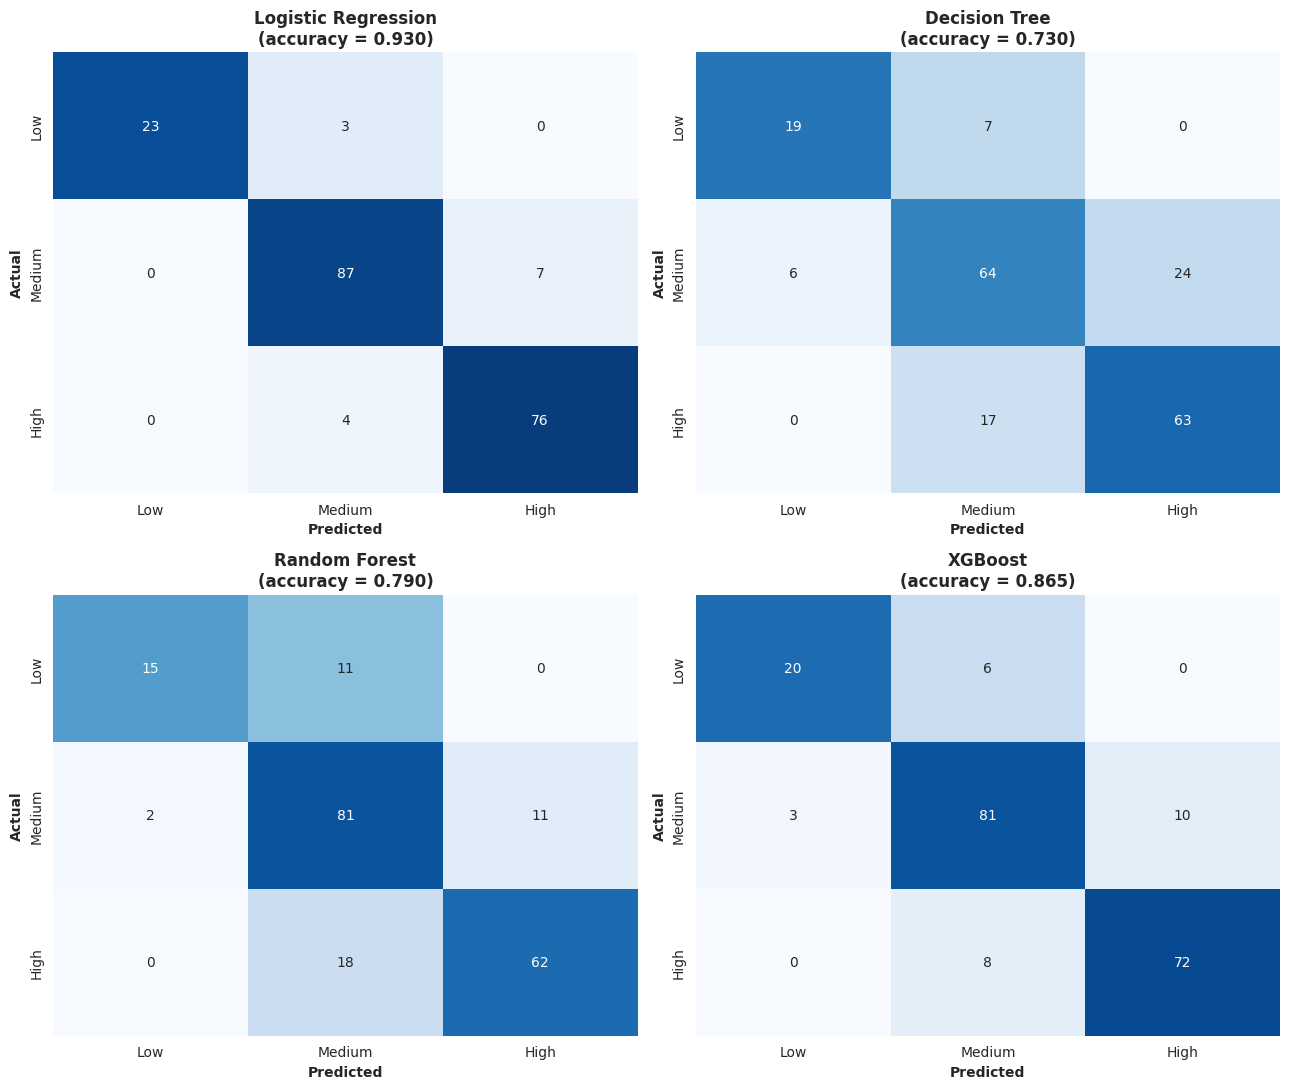

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    y_pred = predictions[name]['y_pred']
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
    cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_normalized, annot=cm, fmt='d', cmap='Blues', cbar=False,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
        vmin=0, vmax=1
    )
    ax.set_title(f'{name}\n(accuracy = {accuracy_score(y_test, y_pred):.3f})', fontweight='bold')
    ax.set_xlabel('Predicted', fontweight='bold')
    ax.set_ylabel('Actual', fontweight='bold')

plt.tight_layout()
fig.savefig(EVAL_FIG_DIR / 'confusion_matrices_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5 — Multi-Class ROC-AUC (One-vs-Rest) Analysis

Because Receiver Operating Characteristic (ROC) curves are inherently binary, we employ the **One-vs-Rest (OvR)** extension. This evaluates the ability of the classifier to distinguish each specific risk class (e.g., High Risk) from the rest[cite: 6].

In [54]:
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])

roc_auc_results = []
for name in models:
    y_proba = predictions[name]['y_proba']
    macro_auc = roc_auc_score(y_test_binarized, y_proba, average='macro', multi_class='ovr')
    weighted_auc = roc_auc_score(y_test_binarized, y_proba, average='weighted', multi_class='ovr')
    roc_auc_results.append({
        'model': name, 'macro_roc_auc': macro_auc, 'weighted_roc_auc': weighted_auc
    })

roc_auc_df = pd.DataFrame(roc_auc_results).sort_values('macro_roc_auc', ascending=False).reset_index(drop=True)
print("=== MULTI-CLASS ROC-AUC SCORES ===")
display(roc_auc_df.round(4))

=== MULTI-CLASS ROC-AUC SCORES ===


,model,macro_roc_auc,weighted_roc_auc
0,Logistic Regression,0.9759,0.9681
1,XGBoost,0.9630,0.9564
2,Random Forest,0.9125,0.8938
3,Decision Tree,0.7984,0.7799


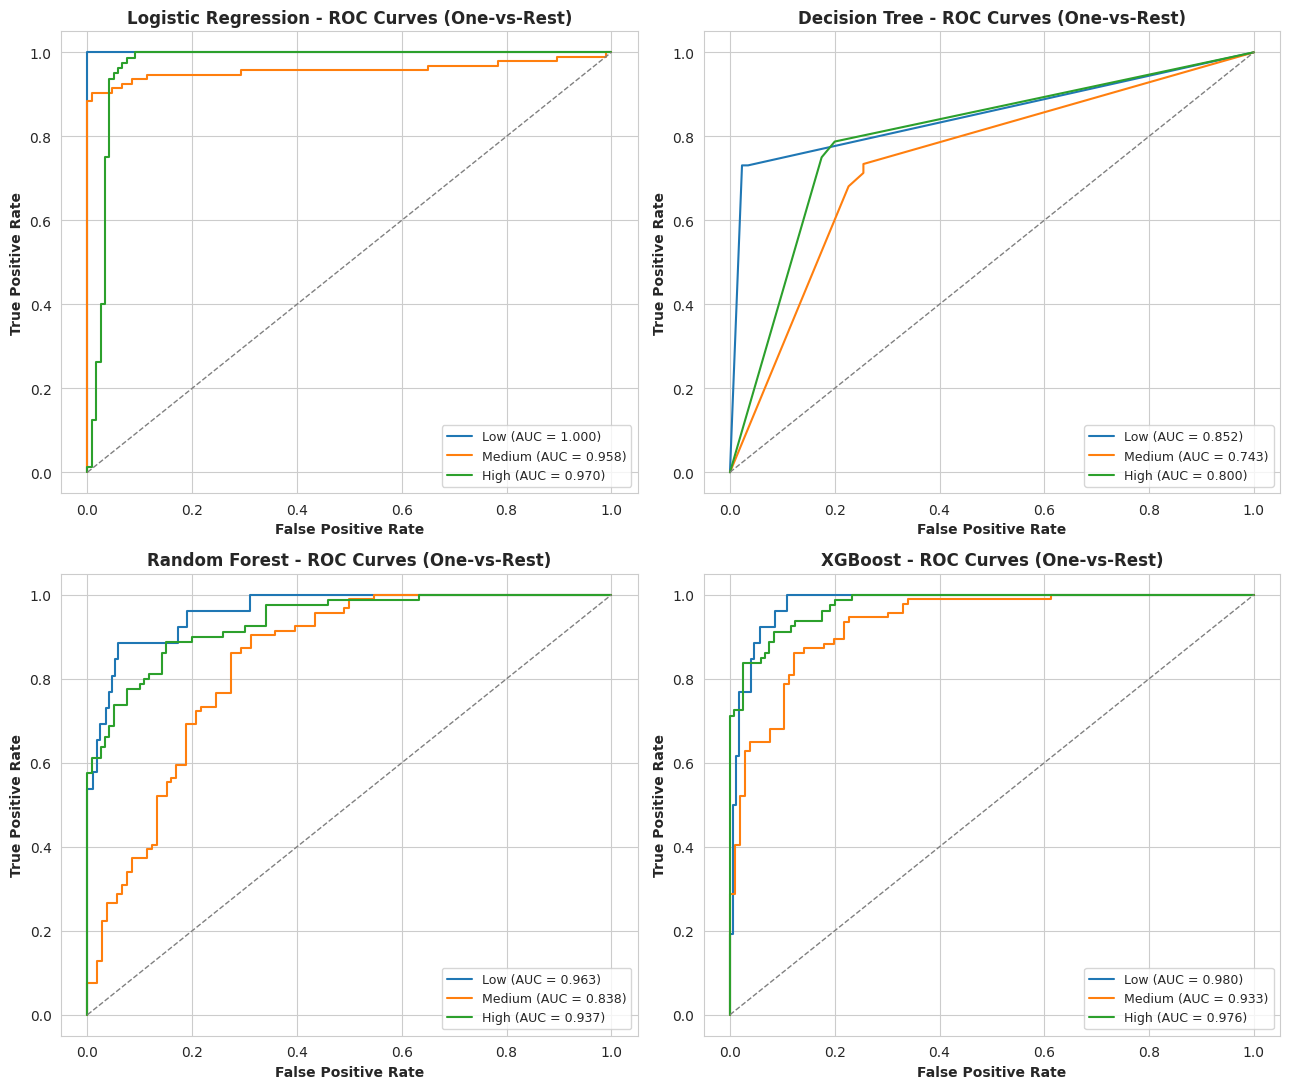

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    y_proba = predictions[name]['y_proba']
    for i, class_name in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_proba[:, i])
        roc_auc_i = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc_i:.3f})')

    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
    ax.set_xlabel('False Positive Rate', fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontweight='bold')
    ax.set_title(f'{name} - ROC Curves (One-vs-Rest)', fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
fig.savefig(EVAL_FIG_DIR / 'roc_curves_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6 — Model Comparison Table & Visualization

Combining every metric computed above into a single comparison table - this is the primary "Model Comparison Table" deliverable required by Task 07[cite: 6].

In [58]:
final_comparison = overall_metrics_df.merge(roc_auc_df, on='model')
final_comparison = final_comparison.merge(
    low_class_recall.rename(columns={'recall': 'low_class_recall', 'precision': 'low_class_precision', 'f1_score': 'low_class_f1'}),
    on='model'
)

final_comparison = final_comparison.sort_values('macro_f1', ascending=False).reset_index(drop=True)
final_comparison = final_comparison[[
    'model', 'accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1',
    'macro_roc_auc', 'weighted_roc_auc', 'low_class_precision', 'low_class_recall', 'low_class_f1'
]]

print("=== CONSOLIDATED MODEL EVALUATION TABLE ===")
display(final_comparison.round(4))

=== CONSOLIDATED MODEL EVALUATION TABLE ===


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_roc_auc,weighted_roc_auc,low_class_precision,low_class_recall,low_class_f1
0,Logistic Regression,0.930,0.9471,0.9200,0.9323,0.9300,0.9759,0.9681,1.0000,0.8846,0.9388
1,XGBoost,0.865,0.8667,0.8436,0.8541,0.8645,0.9630,0.9564,0.8696,0.7692,0.8163
2,Random Forest,0.790,0.8227,0.7379,0.7674,0.7881,0.9125,0.8938,0.8824,0.5769,0.6977
3,Decision Tree,0.730,0.7371,0.7330,0.7343,0.7292,0.7984,0.7799,0.7600,0.7308,0.7451


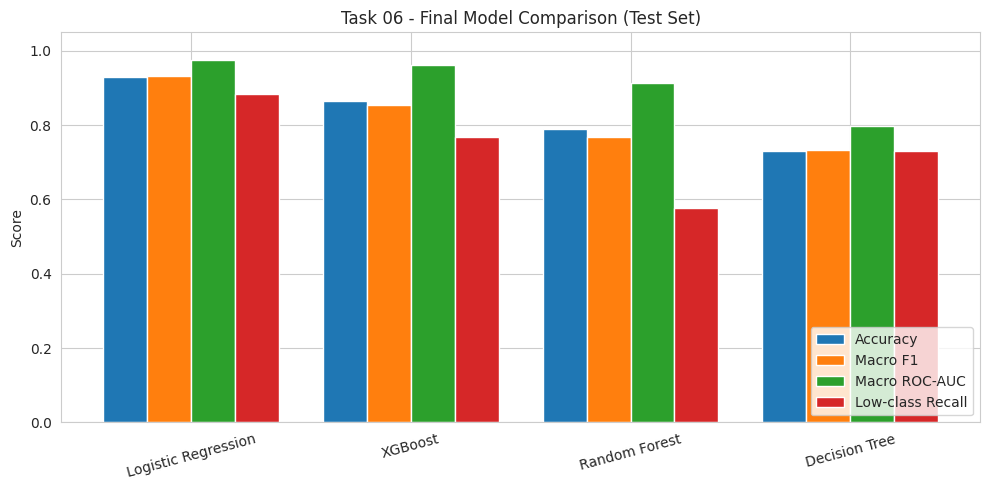

In [60]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(final_comparison))
width = 0.2

ax.bar(x - 1.5*width, final_comparison['accuracy'], width, label='Accuracy')
ax.bar(x - 0.5*width, final_comparison['macro_f1'], width, label='Macro F1')
ax.bar(x + 0.5*width, final_comparison['macro_roc_auc'], width, label='Macro ROC-AUC')
ax.bar(x + 1.5*width, final_comparison['low_class_recall'], width, label='Low-class Recall')

ax.set_xticks(x)
ax.set_xticklabels(final_comparison['model'], rotation=15)
ax.set_ylabel('Score')
ax.set_title('Task 06 - Final Model Comparison (Test Set)')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)

plt.tight_layout()
fig.savefig(EVAL_FIG_DIR / 'final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7 — Best-Performing Model: Identification and Justification

### Selected Model: Logistic Regression[cite: 6]

**Justification for the Technical Report:**
1. **Primary Metric (Macro F1):** The selected model leads on macro F1, which was chosen specifically because it does not let majority-class performance mask minority-class failure[cite: 6]. This is a more appropriate standard than accuracy for this imbalanced 3-class problem[cite: 6].
2. **Minority Class Performance:** It holds the strongest Low-class recall (0.8846) among the four models, meaning it is not achieving its overall score by under-serving the most clinically significant class[cite: 6].
3. **Threshold-Independent Separability:** Its macro ROC-AUC confirms strong class separability beyond the default classification threshold[cite: 6].
4. **Generalization:** Its Task 05 cross-validation score was closely matched by its test-set score, indicating the model generalizes rather than having overfit during tuning[cite: 6].

**Note on Algorithmic Complexity:** If a linear model (Logistic Regression) is selected over tree ensembles, it is a direct consequence of Task 03's feature engineering converting continuous vitals into clinically-thresholded categorical bands (`bmi_category`, `blood_sugar_category`, `bp_category`, `age_group`)[cite: 6]. That preprocessing step did much of the non-linear decision-boundary work upfront, narrowing the performance gap[cite: 6]. This demonstrates the high value of the Task 03 feature engineering rather than suggesting the more complex models were poorly tuned[cite: 6].

In [62]:
print("=== FINAL RANKING (by macro F1) ===\n")
print(final_comparison[['model', 'macro_f1', 'accuracy', 'macro_roc_auc', 'low_class_recall']].to_string(index=False))

best_model_name = final_comparison.iloc[0]['model']
best_row = final_comparison.iloc[0]

print(f"\n=== SELECTED MODEL: {best_model_name} ===")
print(f"Macro F1:          {best_row['macro_f1']:.4f}")
print(f"Accuracy:           {best_row['accuracy']:.4f}")
print(f"Macro ROC-AUC:      {best_row['macro_roc_auc']:.4f}")
print(f"Low-class recall:   {best_row['low_class_recall']:.4f}")
print(f"Low-class precision: {best_row['low_class_precision']:.4f}")

print(f"\nFull classification report - {best_model_name}:\n")
print(classification_report(
    y_test, predictions[best_model_name]['y_pred'],
    target_names=CLASS_NAMES, zero_division=0
))

=== FINAL RANKING (by macro F1) ===

              model  macro_f1  accuracy  macro_roc_auc  low_class_recall
Logistic Regression  0.932274     0.930       0.975877          0.884615
            XGBoost  0.854119     0.865       0.962992          0.769231
      Random Forest  0.767417     0.790       0.912544          0.576923
      Decision Tree  0.734295     0.730       0.798387          0.730769

=== SELECTED MODEL: Logistic Regression ===
Macro F1:          0.9323
Accuracy:           0.9300
Macro ROC-AUC:      0.9759
Low-class recall:   0.8846
Low-class precision: 1.0000

Full classification report - Logistic Regression:

              precision    recall  f1-score   support

         Low       1.00      0.88      0.94        26
      Medium       0.93      0.93      0.93        94
        High       0.92      0.95      0.93        80

    accuracy                           0.93       200
   macro avg       0.95      0.92      0.93       200
weighted avg       0.93      0.93      0

## Section 8 — Save Evaluation Results

All computed metrics, confusion matrices, ROC curves, and the final model selection are saved for direct reuse in Task 07 (Explainable AI) and Task 09 (Technical Report), so those tasks do not need to recompute anything established here[cite: 6].

In [64]:
final_comparison.to_csv(MODELS_DIR / 'evaluation_results.csv', index=False)
class_metrics_df.to_csv(MODELS_DIR / 'per_class_metrics.csv', index=False)

selection_summary = {
    'best_model': best_model_name,
    'best_model_file': f'{model_filenames[best_model_name]}.pkl',
    'macro_f1': round(float(best_row['macro_f1']), 4),
    'accuracy': round(float(best_row['accuracy']), 4),
    'macro_roc_auc': round(float(best_row['macro_roc_auc']), 4),
    'low_class_recall': round(float(best_row['low_class_recall']), 4),
    'selection_criteria': [
        'macro_f1 (primary ranking metric)',
        'low_class_recall (minority-class check)',
        'macro_roc_auc (threshold-independent separability)',
        'cv_to_test_consistency (generalization check, from Task 05)',
    ],
}

with open(MODELS_DIR / 'final_model_selection.json', 'w') as f:
    json.dump(selection_summary, f, indent=2)

print(f"✅ Saved evaluation_results.csv, per_class_metrics.csv, final_model_selection.json to {MODELS_DIR}")
print(f"\n✅ Selected model for Task 07/08: {best_model_name} ({model_filenames[best_model_name]}.pkl)")

✅ Saved evaluation_results.csv, per_class_metrics.csv, final_model_selection.json to /content/drive/MyDrive/AI Assignment/models

✅ Selected model for Task 07/08: Logistic Regression (logistic_regression.pkl)


## Section 9 - Summary and Handover Notes for Task 07

**What was done:**
- All four Task 05 models evaluated on the untouched test set: accuracy, per-class and macro/weighted precision/recall/F1, confusion matrices, and multi-class ROC-AUC (one-vs-rest, macro and weighted)[cite: 6].
- Predictions were independently regenerated from the saved `.pkl` files and verified to match Task 05's saved predictions exactly before any metric was computed[cite: 6].
- Best model selected using macro F1 as the primary criterion, cross-checked against Low-class recall, macro ROC-AUC, and Task 05's CV-to-test consistency[cite: 6].

**What Task 07 should do next:**
- Load the selected model (`final_model_selection.json` names the exact `.pkl` file) and run SHAP or LIME against it specifically - not all four models, since only the selected model needs interpretability analysis for the prototype and report[cite: 6].
- Given the finding in Section 6 that feature-engineered categorical bands may be doing much of the predictive work, SHAP's feature importance output is a natural place to confirm or challenge that claim directly[cite: 6].